In [9]:
from mnist import *
from tqdm import tqdm
import numpy as np

In [10]:
# Aufgabe 1
check_and_download_mnist_files()

x_train = load_mnist_images(TRAIN_IMAGES_PATH)  # trainingsbilder
y_train_raw = load_mnist_labels(TRAIN_LABELS_PATH)  # labels (0-9)

x_test = load_mnist_images(TEST_IMAGES_PATH)
y_test_raw = load_mnist_labels(TEST_LABELS_PATH)

# Labels, die Ziffern sind, werden durch ihre One-Hot-Representation ersetzt
y_train = np.eye(10)[y_train_raw]
y_test = np.eye(10)[y_test_raw]

print(f"Trainingsdaten: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testdaten: {x_test.shape}, Labels: {y_test.shape}")

File mnist/train-images-idx3-ubyte.gz already exists.
File mnist/train-labels-idx1-ubyte.gz already exists.
File mnist/t10k-images-idx3-ubyte.gz already exists.
File mnist/t10k-labels-idx1-ubyte.gz already exists.
Trainingsdaten: (60000, 784), Labels: (60000, 10)
Testdaten: (10000, 784), Labels: (10000, 10)


In [11]:
# Aufgabe 2
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    # axis = 1 sorgt dafür, dass der größte Wert im Batch gesucht wird
    # (für den Trick auf dem Aufgabenblatt)
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / np.sum(e_x, axis=1, keepdims=True)

In [12]:
# Aufgabe 3 (bias für Aufgabe 7 bereits mit drin)
def init_params(input_size=784, hidden_size=100, output_size=10):
    params = {
        # Weights-Matrizen werden zufällig initialisiert.
        # Die Multiplikation mit 0.01 dient dazu, dass die Werte
        # nicht zu groß werden. W1 verbindet die 784 Eingänge mit 128
        # Neuronen, während W2 die 128 Neuronen mit den 10 Ausgängen verbindet.
        # Die Bias-Vektoren werden mit 0 initialisiert.
        "W1": np.random.randn(input_size, hidden_size) * 0.01,
        "b1": np.zeros((1, hidden_size)),
        "W2": np.random.randn(hidden_size, output_size) * 0.01,
        "b2": np.zeros((1, output_size))
    }
    return params


params = init_params()


def forward_pass(X, params):
    # Hidden Layer: z1 = X*W1 + b1
    z1 = np.dot(X, params["W1"]) + params["b1"]
    a1 = relu(z1)

    # Output Layer: z2 = a1*W2 + b2
    z2 = np.dot(a1, params["W2"]) + params["b2"]
    a2 = softmax(z2)

    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2}
    return a2, cache


# Test-Batch erstellen
batch_X = x_train[:32]
predictions, cache = forward_pass(batch_X, params)

print(f"Input Shape: {batch_X.shape}")   # Sollte (32, 784) sein
print(f"Output Shape: {predictions.shape}")  # Sollte (32, 10) sein


Input Shape: (32, 784)
Output Shape: (32, 10)


In [13]:
# Aufgabe 4

def cross_entropy_loss(y_true, y_pred):
    # Ich addiere ein winziges Epsilon, um log(0) zu vermeiden
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    # Ich normalisiere hier nochmal basierend auf der Batch-Größe
    n_samples = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred)) / n_samples
    return loss


def loss_derivative(y_true, y_pred):
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    return - (y_true / y_pred)


def relu_derivative(z):
    return np.where(z > 0, 1, 0)


def output_layer_gradient(y_true, y_pred):
    return y_pred - y_true

In [14]:
# Aufgabe 5
def backward_pass(params, cache, y_true, learning_rate=0.1):
    # Ich hole die gespeicherten Zwischenwerte aus dem Forward Pass
    X = cache["X"]
    a1 = cache["a1"]
    a2 = cache["a2"]
    z1 = cache["z1"]
    n_samples = X.shape[0]

    # Output Layer
    dz2 = output_layer_gradient(y_true, a2)  # Ableitung des loss
    # Berechnung der Auswirkung der Gewichte und des Bias auf den loss
    dW2 = np.dot(a1.T, dz2) / n_samples
    db2 = np.sum(dz2, axis=0, keepdims=True) / n_samples

    # Fehler vom Output Layer wird zum Hidden Layer propagiert
    da1 = np.dot(dz2, params["W2"].T)
    dz1 = da1 * relu_derivative(z1)
    dW1 = np.dot(X.T, dz1) / n_samples
    db1 = np.sum(dz1, axis=0, keepdims=True) / n_samples

    # Updates
    params["W1"] -= learning_rate * dW1
    params["b1"] -= learning_rate * db1
    params["W2"] -= learning_rate * dW2
    params["b2"] -= learning_rate * db2

    return params

Epoche 1/10: 100%|███████████████████████████████████████████████████████████████████| 2400/2400 [00:05<00:00, 453.88it/s, loss=0.1358, acc=96.0%]


Ende Epoche 1. Test Accuracy: 94.5%.


Epoche 2/10: 100%|██████████████████████████████████████████████████████████████████| 2400/2400 [00:05<00:00, 431.19it/s, loss=0.0419, acc=100.0%]


Ende Epoche 2. Test Accuracy: 96.5%.


Epoche 3/10: 100%|██████████████████████████████████████████████████████████████████| 2400/2400 [00:06<00:00, 345.82it/s, loss=0.0278, acc=100.0%]


...

Ende Epoche 8. Test Accuracy: 97.6%.


Epoche 9/10: 100%|███████████████████████████████████████████████████████████████████| 2400/2400 [00:07<00:00, 318.32it/s, loss=0.0835, acc=96.0%]


Ende Epoche 9. Test Accuracy: 97.9%.


Epoche 10/10: 100%|█████████████████████████████████████████████████████████████████| 2400/2400 [00:08<00:00, 283.48it/s, loss=0.0035, acc=100.0%]


Ende Epoche 10. Test Accuracy: 97.7%.
Das Modell sagt: 4


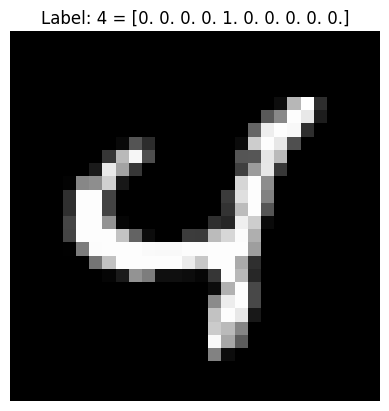

In [15]:
# Aufgabe 6

# Vorhersage-Indizes werden mit den echten Label-Indizes verglichen.
# Die 10 Wahrscheinlichkeiten für jedes Bild, die aus der Softmax-Funktion
# kommen, werden mit argmax auf den höchsten Wert reduziert.
# Der Ausgabewert berechnet den Anteil der korrekten Treffer. Ein Wert von
# 100 bedeutet, dass jedes Bild im Batch richtig erkannt wurde.
def get_accuracy(y_true, y_pred):
    predictions = np.argmax(y_pred, axis=1)
    labels = np.argmax(y_true, axis=1)
    return np.mean(predictions == labels) * 100


def train(X_train, y_train, X_test, y_test, params, epochs=10, batch_size=25, lr=0.1):
    n_samples = X_train.shape[0]

    for epoch in range(epochs):
        # Daten für die Epoche mischen
        permutation = np.random.permutation(n_samples)
        X_shuffled = X_train[permutation]
        y_shuffled = y_train[permutation]

        # Mini-Batch Training
        pbar = tqdm(range(0, n_samples, batch_size), desc=f"Epoche {epoch + 1}/{epochs}")
        for i in pbar:
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            y_pred, cache = forward_pass(X_batch, params)
            loss = cross_entropy_loss(y_batch, y_pred)
            params = backward_pass(params, cache, y_batch, lr)

            # Progress Bar aktualisieren
            if i % 100 == 0:
                acc = get_accuracy(y_batch, y_pred)
                pbar.set_postfix({"loss": f"{loss:.4f}", "acc": f"{acc:.1f}%"})

        # Test-Set Evaluation nach jeder Epoche
        test_pred, _ = forward_pass(X_test, params)
        test_acc = get_accuracy(y_test, test_pred)
        print(f"Ende Epoche {epoch + 1}. Test Accuracy: {test_acc:.1f}%.")

    return params


# Training starten
trained_params = train(x_train, y_train, x_test, y_test, params)

# Ein Beispielbild aus dem Testset wählen
index = 67
test_image = x_test[index:index + 1]
true_label = y_test[index]

# Vorhersage mit trainierten Parametern machen
prediction_probs, _ = forward_pass(test_image, trained_params)
predicted_label_index = np.argmax(prediction_probs)

print(f"Das Modell sagt: {predicted_label_index}")
plot_mnist_example(x_test[index], true_label)
